# Notebook 05: GARCH Volatility VaR

This notebook implements VaR using time-varying volatility models:

1. **Why GARCH?** - Volatility clustering and limitations of constant volatility
2. **GARCH(1,1) Model** - Fitting and parameter estimation
3. **GARCH-Based VaR** - Using conditional volatility
4. **Rolling GARCH VaR** - Dynamic risk estimation
5. **Comparison** - GARCH vs Constant Volatility VaR

---

## 5.1 Why GARCH?

### Volatility Clustering

Financial returns exhibit **volatility clustering**: large returns (positive or negative) tend to be followed by large returns, and small returns by small returns.

The constant volatility assumption ($\sigma$ = constant) used in standard VaR models ignores this phenomenon, leading to:
- **Underestimation of risk** during high-volatility periods
- **Overestimation of risk** during calm periods

### GARCH(1,1) Model

The GARCH(1,1) model (Generalized Autoregressive Conditional Heteroskedasticity) captures time-varying volatility:

$$\sigma^2_t = \omega + \alpha \epsilon^2_{t-1} + \beta \sigma^2_{t-1}$$

Where:
- $\sigma^2_t$ = conditional variance at time t
- $\omega$ = constant (long-run average variance weight)
- $\alpha$ = weight on lagged squared residual (ARCH term)
- $\beta$ = weight on lagged variance (GARCH term)
- $\alpha + \beta$ = persistence (typically 0.9-0.99)

### Interpretation

- **High α**: Volatility reacts quickly to market shocks
- **High β**: Volatility is persistent (decays slowly)
- **α + β close to 1**: High persistence (shocks have long-lasting effects)

In [1]:
# Core libraries
import numpy as np
import pandas as pd
import json
import warnings
warnings.filterwarnings('ignore')

# GARCH modeling
from arch import arch_model

# Statistical
from scipy.stats import norm

# Visualization
import matplotlib.pyplot as plt
import seaborn as sns

# Display
from IPython.display import display, Markdown
pd.set_option('display.float_format', '{:.4f}'.format)
plt.style.use('seaborn-v0_8-whitegrid')

np.random.seed(42)
print("Libraries imported successfully!")

Libraries imported successfully!


In [2]:
# Load configuration and data
with open('../portfolio_config.json', 'r') as f:
    config = json.load(f)

CONFIDENCE = config['var_params']['confidence_var']
TRAIN_START = config['dates']['train_start']
TRAIN_END = config['dates']['train_end']
TEST_START = config['dates']['test_start']
TEST_END = config['dates']['test_end']

# Load returns
portfolio_returns = pd.read_csv('../outputs/portfolio_returns.csv', index_col=0, parse_dates=True)['portfolio_return']

# Convert to percentage for GARCH (better numerical stability)
returns_pct = portfolio_returns * 100

train_returns = returns_pct[TRAIN_START:TRAIN_END]
test_returns = returns_pct[TEST_START:TEST_END]

print(f"Training period: {len(train_returns)} days")
print(f"Testing period: {len(test_returns)} days")

Training period: 731 days
Testing period: 249 days


## 5.2 Evidence of Volatility Clustering

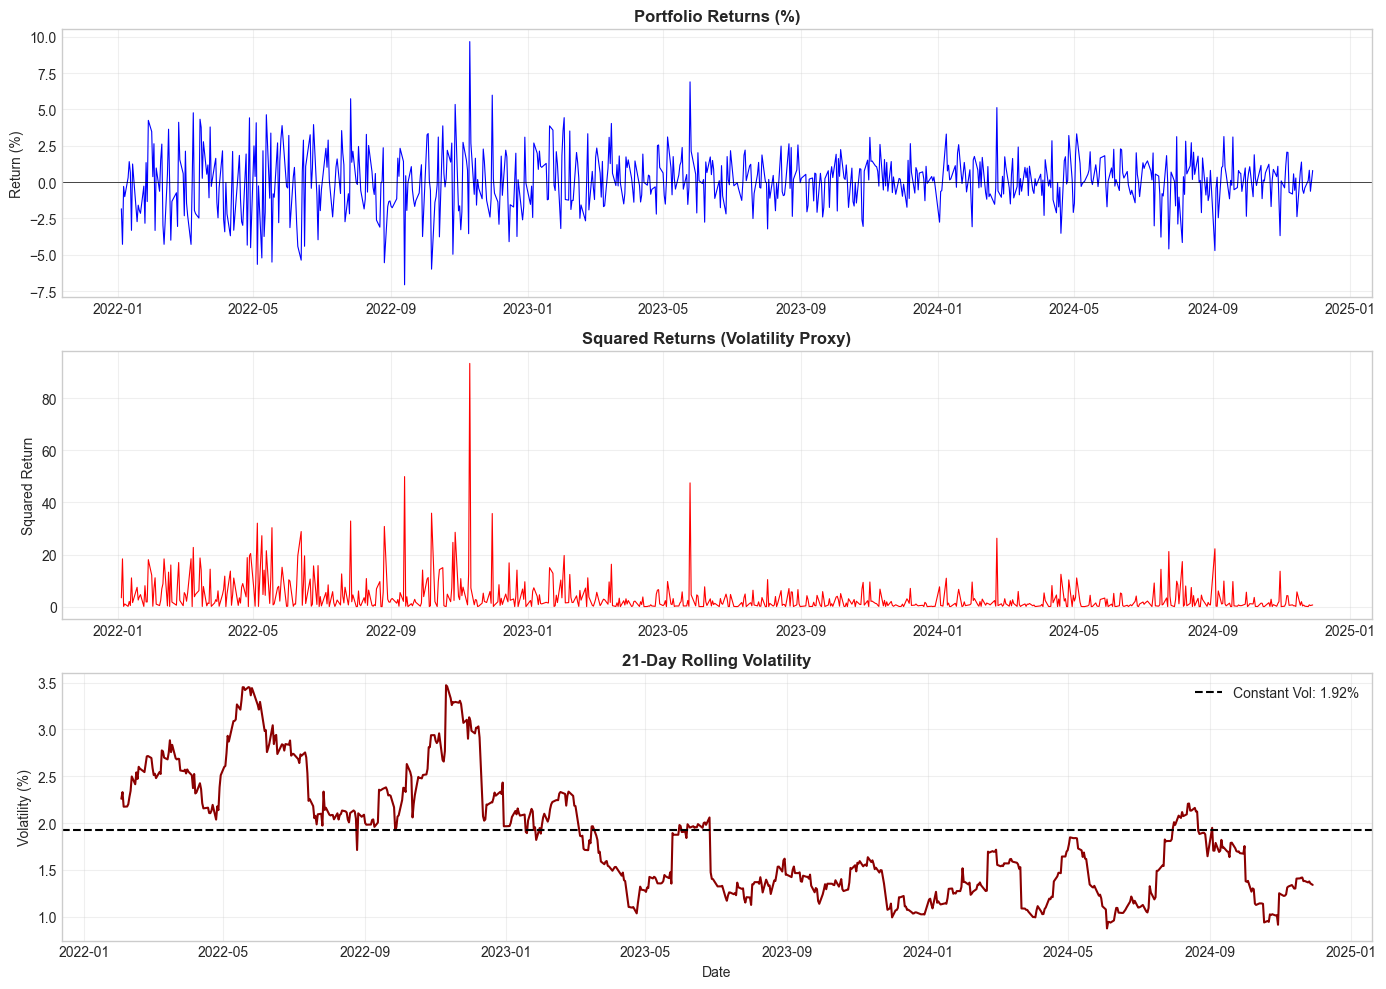

In [3]:
# Visualize volatility clustering
fig, axes = plt.subplots(3, 1, figsize=(14, 10))

# Returns
axes[0].plot(train_returns.index, train_returns.values, color='blue', linewidth=0.8)
axes[0].axhline(0, color='black', linewidth=0.5)
axes[0].set_title('Portfolio Returns (%)', fontsize=12, fontweight='bold')
axes[0].set_ylabel('Return (%)')
axes[0].grid(True, alpha=0.3)

# Squared returns (proxy for volatility)
axes[1].plot(train_returns.index, train_returns.values**2, color='red', linewidth=0.8)
axes[1].set_title('Squared Returns (Volatility Proxy)', fontsize=12, fontweight='bold')
axes[1].set_ylabel('Squared Return')
axes[1].grid(True, alpha=0.3)

# Rolling volatility
rolling_vol = train_returns.rolling(21).std()
axes[2].plot(rolling_vol.index, rolling_vol.values, color='darkred', linewidth=1.5)
axes[2].axhline(train_returns.std(), color='black', linestyle='--', 
                label=f'Constant Vol: {train_returns.std():.2f}%')
axes[2].set_title('21-Day Rolling Volatility', fontsize=12, fontweight='bold')
axes[2].set_ylabel('Volatility (%)')
axes[2].set_xlabel('Date')
axes[2].legend()
axes[2].grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('../outputs/figures/05_volatility_clustering.png', dpi=300, bbox_inches='tight')
plt.show()

In [4]:
# Test for ARCH effects (autocorrelation in squared returns)
from statsmodels.stats.diagnostic import acorr_ljungbox

# Ljung-Box test on squared returns
lb_test = acorr_ljungbox(train_returns**2, lags=[5, 10, 20], return_df=True)

display(Markdown("### Ljung-Box Test for ARCH Effects (Squared Returns)"))
display(lb_test)

display(Markdown("""
**Interpretation:**
- p-value < 0.05: Significant autocorrelation in squared returns → ARCH effects present
- This justifies using GARCH model for volatility
"""))

### Ljung-Box Test for ARCH Effects (Squared Returns)

,lb_stat,lb_pvalue
5,23.7209,0.0002
10,63.4601,0.0000
20,147.7397,0.0000



**Interpretation:**
- p-value < 0.05: Significant autocorrelation in squared returns → ARCH effects present
- This justifies using GARCH model for volatility


## 5.3 Fit GARCH(1,1) Model

In [5]:
def fit_garch(returns, p=1, q=1, dist='normal'):
    """
    Fit a GARCH(p,q) model to returns.
    
    GARCH(1,1) models time-varying volatility:
    σ²_t = ω + α × ε²_{t-1} + β × σ²_{t-1}
    
    Where:
    - ω (omega): constant/intercept term
    - α (alpha): ARCH coefficient - reaction to past shocks
    - β (beta): GARCH coefficient - persistence of volatility
    - ε_{t-1}: previous period's residual (shock)
    - σ²_{t-1}: previous period's variance
    
    Parameters:
    -----------
    returns : pd.Series
        Return series (should be in percentage for numerical stability)
    p : int
        GARCH lag order (number of lagged σ² terms)
    q : int
        ARCH lag order (number of lagged ε² terms)
    dist : str
        Error distribution ('normal', 't', 'skewt')
        
    Returns:
    --------
    arch_model_result
        Fitted model with parameters and diagnostics
    """
    # Create GARCH model specification
    # vol='Garch' specifies GARCH-type volatility model
    # rescale=False keeps returns in original units (percentage)
    model = arch_model(returns, vol='Garch', p=p, q=q, dist=dist, rescale=False)
    
    # Fit model using Maximum Likelihood Estimation (MLE)
    # disp='off' suppresses convergence output
    result = model.fit(disp='off')
    
    return result

In [6]:
# Fit GARCH(1,1) model
garch_model = fit_garch(train_returns, p=1, q=1, dist='normal')

print("GARCH(1,1) Model Summary")
print("="*60)
print(garch_model.summary())

GARCH(1,1) Model Summary
                     Constant Mean - GARCH Model Results                      
Dep. Variable:       portfolio_return   R-squared:                       0.000
Mean Model:             Constant Mean   Adj. R-squared:                  0.000
Vol Model:                      GARCH   Log-Likelihood:               -1468.80
Distribution:                  Normal   AIC:                           2945.60
Method:            Maximum Likelihood   BIC:                           2963.98
                                        No. Observations:                  731
Date:                Fri, Dec 05 2025   Df Residuals:                      730
Time:                        05:49:59   Df Model:                            1
                                 Mean Model                                
                 coef    std err          t      P>|t|     95.0% Conf. Int.
---------------------------------------------------------------------------
mu             0.1213  6.244e-02    

In [7]:
# Extract and interpret GARCH(1,1) parameters
params = garch_model.params

# Core GARCH parameters
omega = params['omega']      # ω: Long-run variance weight (constant term)
alpha = params['alpha[1]']   # α: ARCH effect (reaction to yesterday's shock)
beta = params['beta[1]']     # β: GARCH effect (persistence of yesterday's variance)

# Persistence = α + β
# Measures how long volatility shocks persist
# - Close to 1: Shocks persist for a long time (highly persistent volatility)
# - Close to 0: Shocks die out quickly
# - Must be < 1 for stationarity (volatility doesn't explode)
persistence = alpha + beta

# Long-run (unconditional) variance
# As t → ∞, E[σ²] = ω / (1 - α - β)
# This is the variance level the process reverts to over time
long_run_var = omega / (1 - alpha - beta)
long_run_vol = np.sqrt(long_run_var)  # Convert variance to volatility (std dev)

# Half-life of volatility shocks
# Time (in days) for a shock to decay to 50% of its initial impact
# Formula: half_life = ln(0.5) / ln(persistence)
half_life = np.log(0.5) / np.log(persistence)

display(Markdown(f"""
### GARCH(1,1) Parameters

| Parameter | Value | Interpretation |
|-----------|-------|----------------|
| ω (omega) | {omega:.6f} | Constant term |
| α (alpha) | {alpha:.4f} | ARCH effect (reaction to shocks) |
| β (beta) | {beta:.4f} | GARCH effect (persistence) |
| α + β | {persistence:.4f} | Total persistence |

### Derived Metrics

| Metric | Value | Interpretation |
|--------|-------|----------------|
| Long-run volatility | {long_run_vol:.2f}% | Unconditional volatility level |
| Half-life | {half_life:.1f} days | Time for shock to decay 50% |
| Persistence | {persistence:.4f} | {'High' if persistence > 0.95 else 'Moderate'} persistence |

**Interpretation:**
- High β ({beta:.2f}) indicates volatility is persistent
- Shocks take approximately {half_life:.0f} days to decay by half
- The sum α + β = {persistence:.4f} is {'close to 1, indicating high persistence' if persistence > 0.95 else 'moderate'}
"""))


### GARCH(1,1) Parameters

| Parameter | Value | Interpretation |
|-----------|-------|----------------|
| ω (omega) | 0.010707 | Constant term |
| α (alpha) | 0.0203 | ARCH effect (reaction to shocks) |
| β (beta) | 0.9749 | GARCH effect (persistence) |
| α + β | 0.9952 | Total persistence |

### Derived Metrics

| Metric | Value | Interpretation |
|--------|-------|----------------|
| Long-run volatility | 1.50% | Unconditional volatility level |
| Half-life | 145.5 days | Time for shock to decay 50% |
| Persistence | 0.9952 | High persistence |

**Interpretation:**
- High β (0.97) indicates volatility is persistent
- Shocks take approximately 145 days to decay by half
- The sum α + β = 0.9952 is close to 1, indicating high persistence


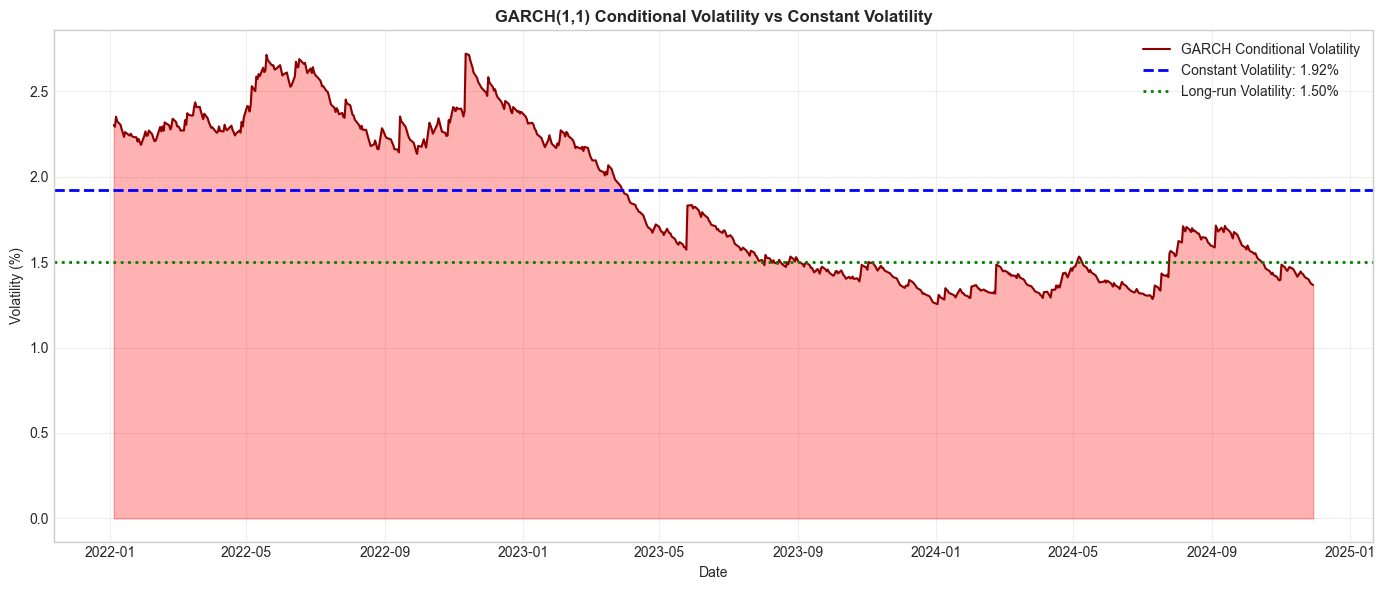

In [8]:
# Plot conditional volatility
conditional_vol = garch_model.conditional_volatility

fig, ax = plt.subplots(figsize=(14, 6))

ax.plot(conditional_vol.index, conditional_vol.values, color='darkred', 
        linewidth=1.5, label='GARCH Conditional Volatility')
ax.axhline(train_returns.std(), color='blue', linestyle='--', linewidth=2,
           label=f'Constant Volatility: {train_returns.std():.2f}%')
ax.axhline(long_run_vol, color='green', linestyle=':', linewidth=2,
           label=f'Long-run Volatility: {long_run_vol:.2f}%')

ax.fill_between(conditional_vol.index, 0, conditional_vol.values, alpha=0.3, color='red')

ax.set_title('GARCH(1,1) Conditional Volatility vs Constant Volatility', fontsize=12, fontweight='bold')
ax.set_xlabel('Date')
ax.set_ylabel('Volatility (%)')
ax.legend(loc='upper right')
ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('../outputs/figures/05_conditional_volatility.png', dpi=300, bbox_inches='tight')
plt.show()

## 5.4 GARCH-Based VaR

In [9]:
def garch_var(model, confidence=0.99):
    """
    Calculate VaR using GARCH model's 1-step ahead volatility forecast.
    
    Unlike constant volatility VaR, GARCH VaR uses the forecasted
    conditional volatility for the next period, making it responsive
    to recent market conditions.
    
    Parameters:
    -----------
    model : arch_model_result
        Fitted GARCH model
    confidence : float
        VaR confidence level
        
    Returns:
    --------
    tuple
        (var, forecasted_volatility)
    """
    # Step 1: Forecast 1-step ahead variance using GARCH model
    # The model uses current information to predict tomorrow's volatility:
    # σ²_{t+1} = ω + α × ε²_t + β × σ²_t
    forecast = model.forecast(horizon=1)
    
    # Extract the forecasted variance (last row, first column)
    forecasted_var = forecast.variance.iloc[-1, 0]
    
    # Convert variance to volatility (standard deviation)
    forecasted_vol = np.sqrt(forecasted_var)
    
    # Step 2: Calculate VaR using forecasted volatility
    # VaR = μ + z × σ_forecast
    z_score = norm.ppf(1 - confidence)  # e.g., -2.326 for 99%
    
    # Get mean return from model (if estimated)
    mu = model.params['mu'] if 'mu' in model.params else 0
    
    # Calculate VaR
    var = mu + z_score * forecasted_vol
    
    return var, forecasted_vol

In [10]:
# Calculate GARCH VaR
garch_var_99, forecast_vol = garch_var(garch_model, CONFIDENCE)

# Convert back to decimal
garch_var_99_decimal = garch_var_99 / 100
forecast_vol_decimal = forecast_vol / 100

# Compare with constant volatility VaR
const_vol = train_returns.std()
const_var_99 = norm.ppf(1 - CONFIDENCE) * const_vol
const_var_99_decimal = const_var_99 / 100

print("GARCH-Based VaR vs Constant Volatility VaR")
print("="*60)
print(f"\nGARCH 1-Step Ahead Forecasted Volatility: {forecast_vol:.2f}%")
print(f"Constant (Historical) Volatility: {const_vol:.2f}%")
print(f"\n99% GARCH VaR: {garch_var_99:.2f}% ({abs(garch_var_99_decimal):.2%} potential loss)")
print(f"99% Constant VaR: {const_var_99:.2f}% ({abs(const_var_99_decimal):.2%} potential loss)")
print(f"\nDifference: {abs(garch_var_99) - abs(const_var_99):.2f}%")

GARCH-Based VaR vs Constant Volatility VaR

GARCH 1-Step Ahead Forecasted Volatility: 1.36%
Constant (Historical) Volatility: 1.92%

99% GARCH VaR: -3.03% (3.03% potential loss)
99% Constant VaR: -4.48% (4.48% potential loss)

Difference: -1.44%


## 5.5 Rolling GARCH VaR

In [11]:
def rolling_garch_var(returns, window=250, confidence=0.99):
    """
    Calculate rolling GARCH VaR.
    
    Parameters:
    -----------
    returns : pd.Series
        Full return series (training + test)
    window : int
        Rolling window for GARCH estimation
    confidence : float
        VaR confidence level
        
    Returns:
    --------
    pd.DataFrame
        DataFrame with dates, actual returns, rolling VaR, and conditional volatility
    """
    z_score = norm.ppf(1 - confidence)
    
    rolling_results = []
    
    for i in range(window, len(returns)):
        # Get rolling window
        window_returns = returns.iloc[i-window:i]
        
        try:
            # Fit GARCH on window
            model = arch_model(window_returns, vol='Garch', p=1, q=1, rescale=False)
            result = model.fit(disp='off')
            
            # Get conditional volatility at end of window
            cond_vol = result.conditional_volatility.iloc[-1]
            
            # Forecast next day volatility
            forecast = result.forecast(horizon=1)
            forecast_vol = np.sqrt(forecast.variance.iloc[-1, 0])
            
            # Calculate VaR
            var = z_score * forecast_vol
            
            rolling_results.append({
                'Date': returns.index[i],
                'Actual_Return': returns.iloc[i],
                'Rolling_GARCH_VaR': var,
                'Conditional_Vol': cond_vol,
                'Forecasted_Vol': forecast_vol
            })
        except:
            continue
    
    return pd.DataFrame(rolling_results).set_index('Date')

In [12]:
# Calculate rolling GARCH VaR (this may take a few minutes)
print("Calculating rolling GARCH VaR (this may take a few minutes)...")

full_returns_pct = portfolio_returns * 100
rolling_garch = rolling_garch_var(full_returns_pct, window=250, confidence=CONFIDENCE)

print(f"Calculated {len(rolling_garch)} rolling GARCH VaR estimates")
display(rolling_garch.head())

Calculating rolling GARCH VaR (this may take a few minutes)...
Calculated 732 rolling GARCH VaR estimates


,Actual_Return,Rolling_GARCH_VaR,Conditional_Vol,Forecasted_Vol
Date,,,,
2023-01-03,-1.5355,-5.9667,2.5649,2.5649
2023-01-04,-0.2800,-5.9548,2.5597,2.5597
2023-01-05,-2.4380,-5.9493,2.5573,2.5573
2023-01-06,2.6894,-5.9437,2.5550,2.5550
2023-01-09,1.9824,-5.9452,2.5556,2.5556


In [13]:
# Also calculate rolling constant volatility VaR for comparison
full_returns = portfolio_returns
rolling_const_vol = full_returns.rolling(250).std() * 100
rolling_const_var = norm.ppf(1 - CONFIDENCE) * rolling_const_vol

# Align indices
common_idx = rolling_garch.index.intersection(rolling_const_var.dropna().index)

rolling_garch_aligned = rolling_garch.loc[common_idx]
rolling_const_aligned = rolling_const_var.loc[common_idx]

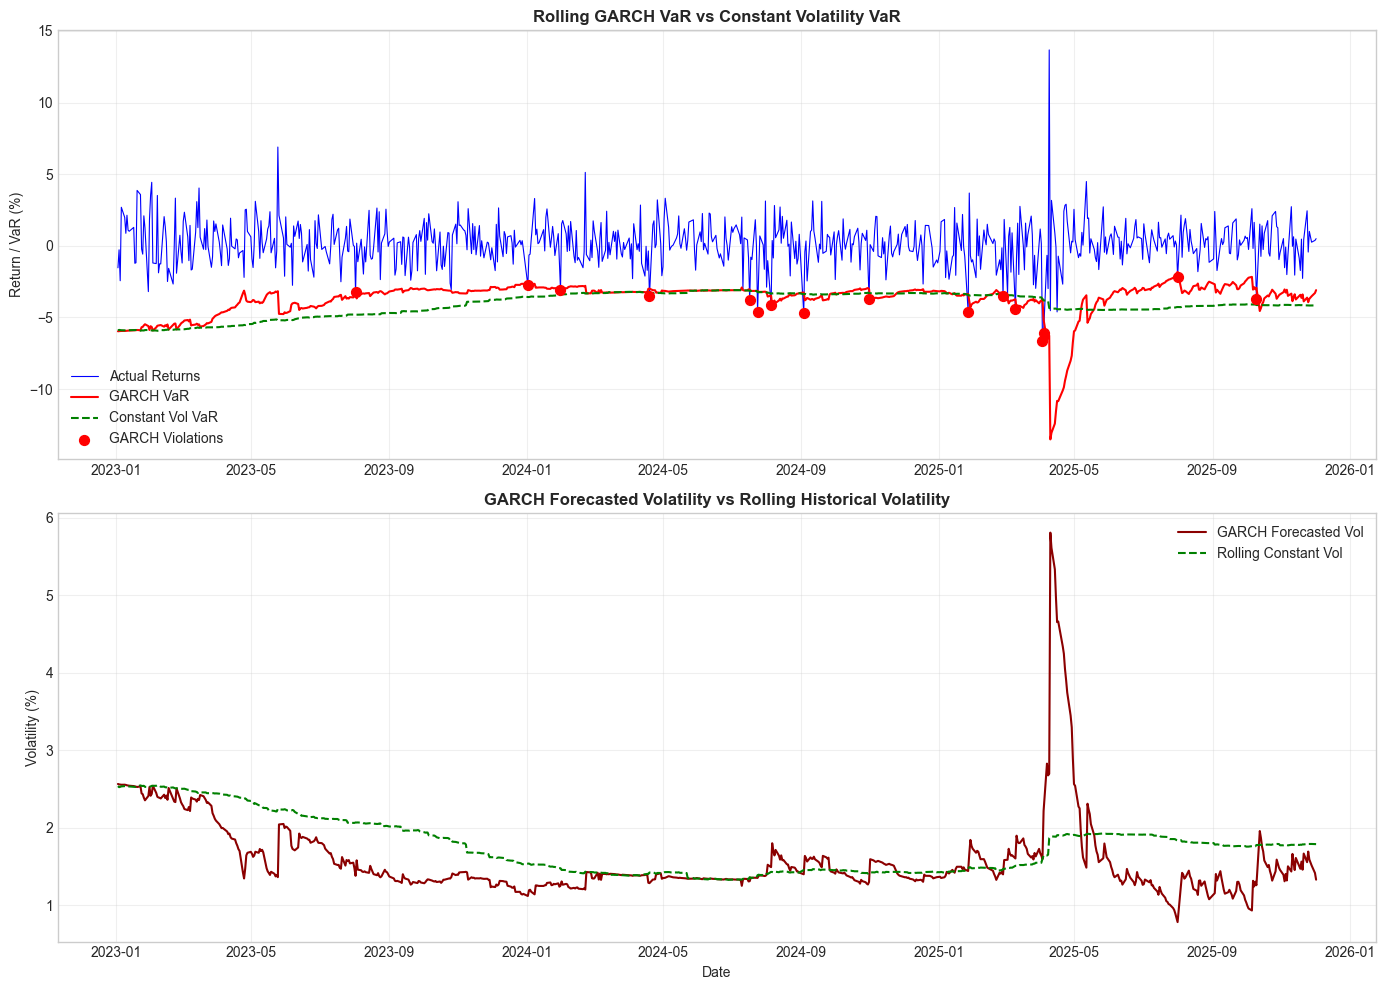

In [14]:
# Visualize rolling GARCH VaR vs Constant VaR
fig, axes = plt.subplots(2, 1, figsize=(14, 10))

# Top: Returns with VaR lines
ax1 = axes[0]
ax1.plot(rolling_garch_aligned.index, rolling_garch_aligned['Actual_Return'], 
         color='blue', linewidth=0.8, label='Actual Returns')
ax1.plot(rolling_garch_aligned.index, rolling_garch_aligned['Rolling_GARCH_VaR'], 
         color='red', linewidth=1.5, label='GARCH VaR')
ax1.plot(rolling_const_aligned.index, rolling_const_aligned.values, 
         color='green', linewidth=1.5, linestyle='--', label='Constant Vol VaR')

# Highlight violations
violations_garch = rolling_garch_aligned['Actual_Return'] < rolling_garch_aligned['Rolling_GARCH_VaR']
ax1.scatter(rolling_garch_aligned.index[violations_garch], 
            rolling_garch_aligned.loc[violations_garch, 'Actual_Return'],
            color='red', s=50, zorder=5, label='GARCH Violations')

ax1.set_title('Rolling GARCH VaR vs Constant Volatility VaR', fontsize=12, fontweight='bold')
ax1.set_ylabel('Return / VaR (%)')
ax1.legend(loc='lower left')
ax1.grid(True, alpha=0.3)

# Bottom: Conditional volatility comparison
ax2 = axes[1]
ax2.plot(rolling_garch_aligned.index, rolling_garch_aligned['Forecasted_Vol'], 
         color='darkred', linewidth=1.5, label='GARCH Forecasted Vol')
ax2.plot(rolling_const_vol.loc[common_idx].index, rolling_const_vol.loc[common_idx].values, 
         color='green', linewidth=1.5, linestyle='--', label='Rolling Constant Vol')

ax2.set_title('GARCH Forecasted Volatility vs Rolling Historical Volatility', fontsize=12, fontweight='bold')
ax2.set_xlabel('Date')
ax2.set_ylabel('Volatility (%)')
ax2.legend()
ax2.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('../outputs/figures/05_rolling_garch_var.png', dpi=300, bbox_inches='tight')
plt.show()

## 5.6 GARCH vs Constant Volatility Comparison

In [15]:
# Count violations for each method
violations_garch = (rolling_garch_aligned['Actual_Return'] < rolling_garch_aligned['Rolling_GARCH_VaR']).sum()
violations_const = (rolling_garch_aligned['Actual_Return'] < rolling_const_aligned).sum()

total_days = len(rolling_garch_aligned)
expected_violations = total_days * (1 - CONFIDENCE)

comparison = pd.DataFrame({
    'Metric': ['Total Days', 'Expected Violations (1%)', 'Actual Violations', 'Violation Rate', 'Basel Zone'],
    'GARCH VaR': [
        total_days, 
        f"{expected_violations:.1f}",
        violations_garch, 
        f"{violations_garch/total_days*100:.2f}%",
        'Green' if violations_garch <= 4 else ('Yellow' if violations_garch <= 9 else 'Red')
    ],
    'Constant Vol VaR': [
        total_days, 
        f"{expected_violations:.1f}",
        violations_const, 
        f"{violations_const/total_days*100:.2f}%",
        'Green' if violations_const <= 4 else ('Yellow' if violations_const <= 9 else 'Red')
    ]
})

display(Markdown("### GARCH VaR vs Constant Volatility VaR Performance"))
display(comparison)

### GARCH VaR vs Constant Volatility VaR Performance

,Metric,GARCH VaR,Constant Vol VaR
0,Total Days,732,732
1,Expected Violations (1%),7.3,7.3
2,Actual Violations,16,13
3,Violation Rate,2.19%,1.78%
4,Basel Zone,Red,Red


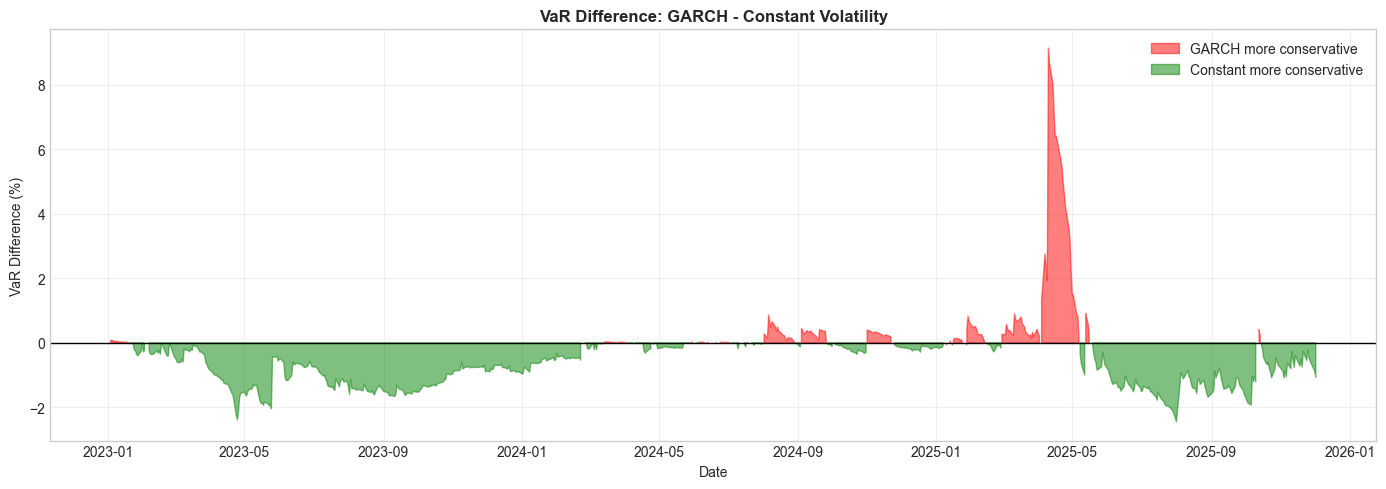

Average VaR Difference: -0.42%
Days GARCH more conservative: 180 (24.6%)
Days Constant more conservative: 552 (75.4%)


In [16]:
# VaR difference analysis
var_difference = abs(rolling_garch_aligned['Rolling_GARCH_VaR']) - abs(rolling_const_aligned)

fig, ax = plt.subplots(figsize=(14, 5))

ax.fill_between(var_difference.index, 0, var_difference.values,
                where=var_difference > 0, color='red', alpha=0.5, 
                label='GARCH more conservative')
ax.fill_between(var_difference.index, 0, var_difference.values,
                where=var_difference <= 0, color='green', alpha=0.5, 
                label='Constant more conservative')
ax.axhline(0, color='black', linewidth=1)

ax.set_title('VaR Difference: GARCH - Constant Volatility', fontsize=12, fontweight='bold')
ax.set_xlabel('Date')
ax.set_ylabel('VaR Difference (%)')
ax.legend()
ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('../outputs/figures/05_var_difference.png', dpi=300, bbox_inches='tight')
plt.show()

print(f"Average VaR Difference: {var_difference.mean():.2f}%")
print(f"Days GARCH more conservative: {(var_difference > 0).sum()} ({(var_difference > 0).mean()*100:.1f}%)")
print(f"Days Constant more conservative: {(var_difference <= 0).sum()} ({(var_difference <= 0).mean()*100:.1f}%)")

## 5.7 Save Results

In [17]:
# Save GARCH results
garch_results = {
    'model_params': {
        'omega': float(omega),
        'alpha': float(alpha),
        'beta': float(beta),
        'persistence': float(persistence)
    },
    'derived_metrics': {
        'long_run_volatility_pct': float(long_run_vol),
        'half_life_days': float(half_life)
    },
    'var_99_pct': float(garch_var_99),
    'forecasted_vol_pct': float(forecast_vol),
    'comparison': {
        'garch_violations': int(violations_garch),
        'const_violations': int(violations_const),
        'total_days': int(total_days)
    }
}

with open('../outputs/garch_results.json', 'w') as f:
    json.dump(garch_results, f, indent=4)

# Save rolling results
rolling_garch.to_csv('../outputs/rolling_garch_var.csv')

print("GARCH results saved:")
print("  - outputs/garch_results.json")
print("  - outputs/rolling_garch_var.csv")

GARCH results saved:
  - outputs/garch_results.json
  - outputs/rolling_garch_var.csv


---

## Summary

In this notebook, we implemented GARCH-based VaR:

### GARCH(1,1) Model Results

| Parameter | Interpretation |
|-----------|---------------|
| α (ARCH) | Reaction to market shocks |
| β (GARCH) | Volatility persistence |
| α + β | Total persistence |

### Key Findings

1. **Volatility Clustering**: Strong evidence of time-varying volatility
2. **High Persistence**: Volatility shocks decay slowly
3. **Dynamic VaR**: GARCH VaR adapts to market conditions
4. **Comparison**:
   - GARCH is more conservative during high-volatility periods
   - Constant vol is more conservative during calm periods

### When to Use GARCH VaR

- After major market shocks (volatility elevated)
- When volatility clustering is evident
- For more responsive risk management

**Next Steps:**
In Notebook 06, we will implement comprehensive backtesting including Basel III framework, Kupiec test, and Christoffersen test.